# Explore here

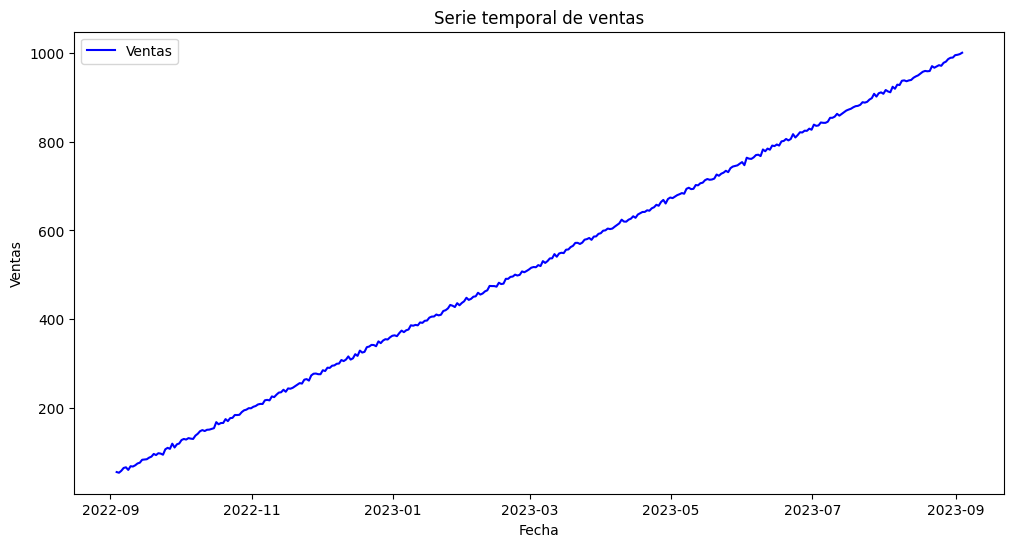

Tensor de la serie temporal: None
Estadística de prueba de ADF: 0.5454141937063742, Valor p: 0.9861899815311063


/home/vscode/.local/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/vscode/.local/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/vscode/.local/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/vscode/.local/lib/python3.11/site-packages/statsmodels/tsa/statespace/representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['typ']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


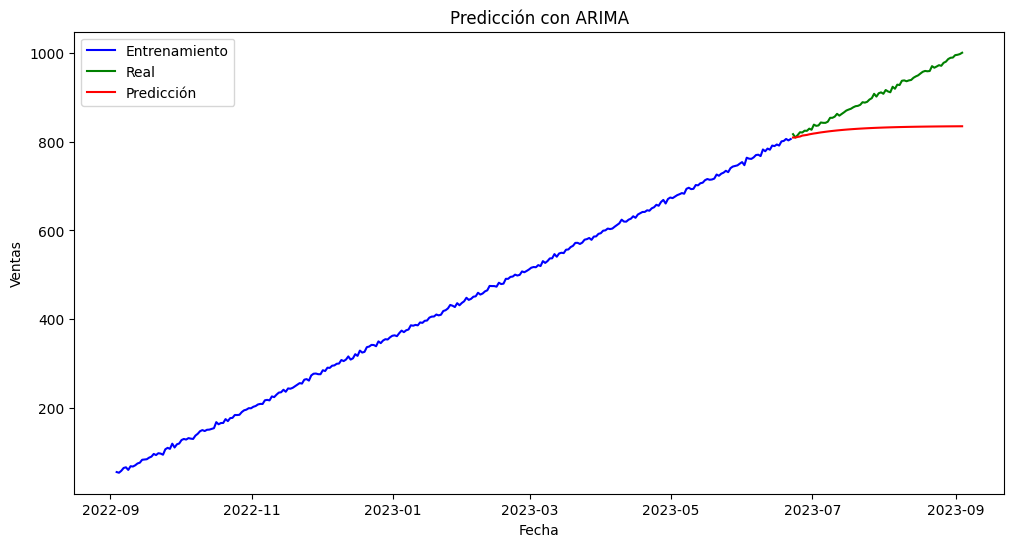

Error MAE del modelo ARIMA: 76.3115


['arima_model.pkl']

In [2]:
# Your code here

 
import pandas as pd  # Para manejar el conjunto de datos
import numpy as np  # Para realizar cálculos matemáticos
import matplotlib.pyplot as plt  # Para graficar resultados
from statsmodels.tsa.stattools import adfuller  # Para verificar estacionariedad
from statsmodels.tsa.arima.model import ARIMA  # Para implementar el modelo ARIMA
from sklearn.metrics import mean_absolute_error  # Para medir el rendimiento de las predicciones
import joblib  # Para almacenar el modelo entrenado

# Paso 1: Carga del conjunto de datos
url = "https://raw.githubusercontent.com/4GeeksAcademy/alternative-time-series-project/main/sales.csv"
df = pd.read_csv(url, parse_dates=["date"], index_col="date")  # Cargamos el dataset y establecemos 'date' como índice

# Paso 2: Construcción y análisis de la serie temporal
plt.figure(figsize=(12, 6))
plt.plot(df, label="Ventas", color="blue")  # Graficamos la serie temporal
plt.xlabel("Fecha")
plt.ylabel("Ventas")
plt.title("Serie temporal de ventas")
plt.legend()
plt.show()

 
tensor = df.index.freq  # Determinar la unidad mínima de tiempo en la serie
result = adfuller(df["sales"])  # Prueba de Dickey-Fuller para verificar estacionariedad
print(f"Tensor de la serie temporal: {tensor}")
print(f"Estadística de prueba de ADF: {result[0]}, Valor p: {result[1]}")  # Interpretación de estacionariedad

# Paso 3: Entrenamiento del modelo ARIMA
train_size = int(len(df) * 0.8)  # Definir tamaño del conjunto de entrenamiento
train, test = df[:train_size], df[train_size:]  # División en entrenamiento y prueba
model = ARIMA(train, order=(5,1,0))  # Inicializar el modelo ARIMA con parámetros base
model_fit = model.fit()  # Ajustar el modelo ARIMA

# Paso 4: Predicción con el conjunto de prueba
predictions = model_fit.predict(start=len(train), end=len(df)-1, typ="levels")  # Generar predicciones
error = mean_absolute_error(test["sales"], predictions)  # Calcular error
plt.figure(figsize=(12, 6))
plt.plot(train, label="Entrenamiento", color="blue")
plt.plot(test, label="Real", color="green")
plt.plot(predictions, label="Predicción", color="red")  # Graficar predicciones vs valores reales
plt.xlabel("Fecha")
plt.ylabel("Ventas")
plt.title("Predicción con ARIMA")
plt.legend()
plt.show()
print(f"Error MAE del modelo ARIMA: {error:.4f}")

# Paso 5: Guardado del modelo entrenado
joblib.dump(model_fit, "arima_model.pkl")  # Guardamos el modelo ARIMA en un archivo